# Multi-Config Early Stopping Experiment

**Goal:** Run GD on multiple configurations, save results as `.pkl` files, and plot from saved data.

**Structure:**
1. **Cell 1 — Config:** Define experiment configurations
2. **Cell 2 — Compute:** Run GD, compute w_tilde, save results
3. **Cell 3 — Plot:** Load saved results and plot (no recomputation needed)

In [9]:
# Cell 1 — Config
# Define your experiment configurations here.
# Each dict can optionally include 'eigenvalues', 'w_star', 'eta'.
# If omitted, defaults to power_law_config and theoretical_eta.

configs = [
    {"n": 200,  "d": 500,  "k": 10,  "seed": 4},
    {"n": 200,  "d": 500,  "k": 10, "seed": 2},
    # {"n": 500,  "d": 1000, "k": 5,  "seed": 0},
    # {"n": 500,  "d": 1000, "k": 10, "seed": 0},
    # {"n": 1000, "d": 2000, "k": 5,  "seed": 0},
    # {"n": 1000, "d": 2000, "k": 10, "seed": 0},
]

NUM_ITERATIONS = 100000
TRACK_POPULATION_LOSS = True   # Set to False to skip (saves time)
POP_SAMPLES_PER_DIM = 25       # MC samples = POP_SAMPLES_PER_DIM * d

In [10]:
# Cell 2 — Compute
# Run GD for each config, compute w_tilde, save results to results/ folder.
# Skip this cell if you already have saved .pkl files.

from configs import create_model, run_and_save

models = []
for i, cfg in enumerate(configs):
    print(f"\n{'='*60}")
    print(f"Config {i+1}/{len(configs)}: {cfg}")
    print(f"{'='*60}")

    model = create_model(**cfg)
    model.generate_data()
    model.run_gd(NUM_ITERATIONS,
                 track_population_loss=TRACK_POPULATION_LOSS,
                 pop_samples_per_dim=POP_SAMPLES_PER_DIM)
    model.compute_max_margin_direction()
    run_and_save(model, save_dir="results")
    models.append(model)

print(f"\nDone. {len(models)} runs saved to results/")


Config 1/2: {'n': 200, 'd': 500, 'k': 10, 'seed': 4}
Parameters: d=500, n=200, k=10
tr(Sigma) = 1.6429
eta (used) = 0.187550
Data generated: X shape = (200, 500), y shape = (200,)
Label balance: 54.00% positive
  t=       0: loss=0.693147, ||w||=0.0000
Continuing GD from t=0 to t=100000...
  L_hat(w*_0:k) = 0.632813
  t=    2000: loss=0.572144, ||w||=4.8880
  t=    4000: loss=0.549586, ||w||=7.4820
  t=    6000: loss=0.533549, ||w||=9.6391
  t=    8000: loss=0.520125, ||w||=11.6230
  t=   10000: loss=0.508285, ||w||=13.5098
  t=   12000: loss=0.497584, ||w||=15.3256
  t=   14000: loss=0.487766, ||w||=17.0820
  t=   16000: loss=0.478662, ||w||=18.7863
  t=   18000: loss=0.470154, ||w||=20.4434
  t=   20000: loss=0.462154, ||w||=22.0575
  t=   22000: loss=0.454595, ||w||=23.6322
  t=   24000: loss=0.447424, ||w||=25.1704
  t=   26000: loss=0.440600, ||w||=26.6746
  t=   28000: loss=0.434088, ||w||=28.1473
  t=   30000: loss=0.427858, ||w||=29.5902
  t=   32000: loss=0.421887, ||w||=31.0

Found 5 saved runs:
  results/run_n100_d200_k10_seed0.pkl
  results/run_n200_d500_k10_seed0.pkl
  results/run_n200_d500_k10_seed1.pkl
  results/run_n200_d500_k10_seed2.pkl
  results/run_n200_d500_k10_seed4.pkl

Plotting: results/run_n100_d200_k10_seed0.pkl


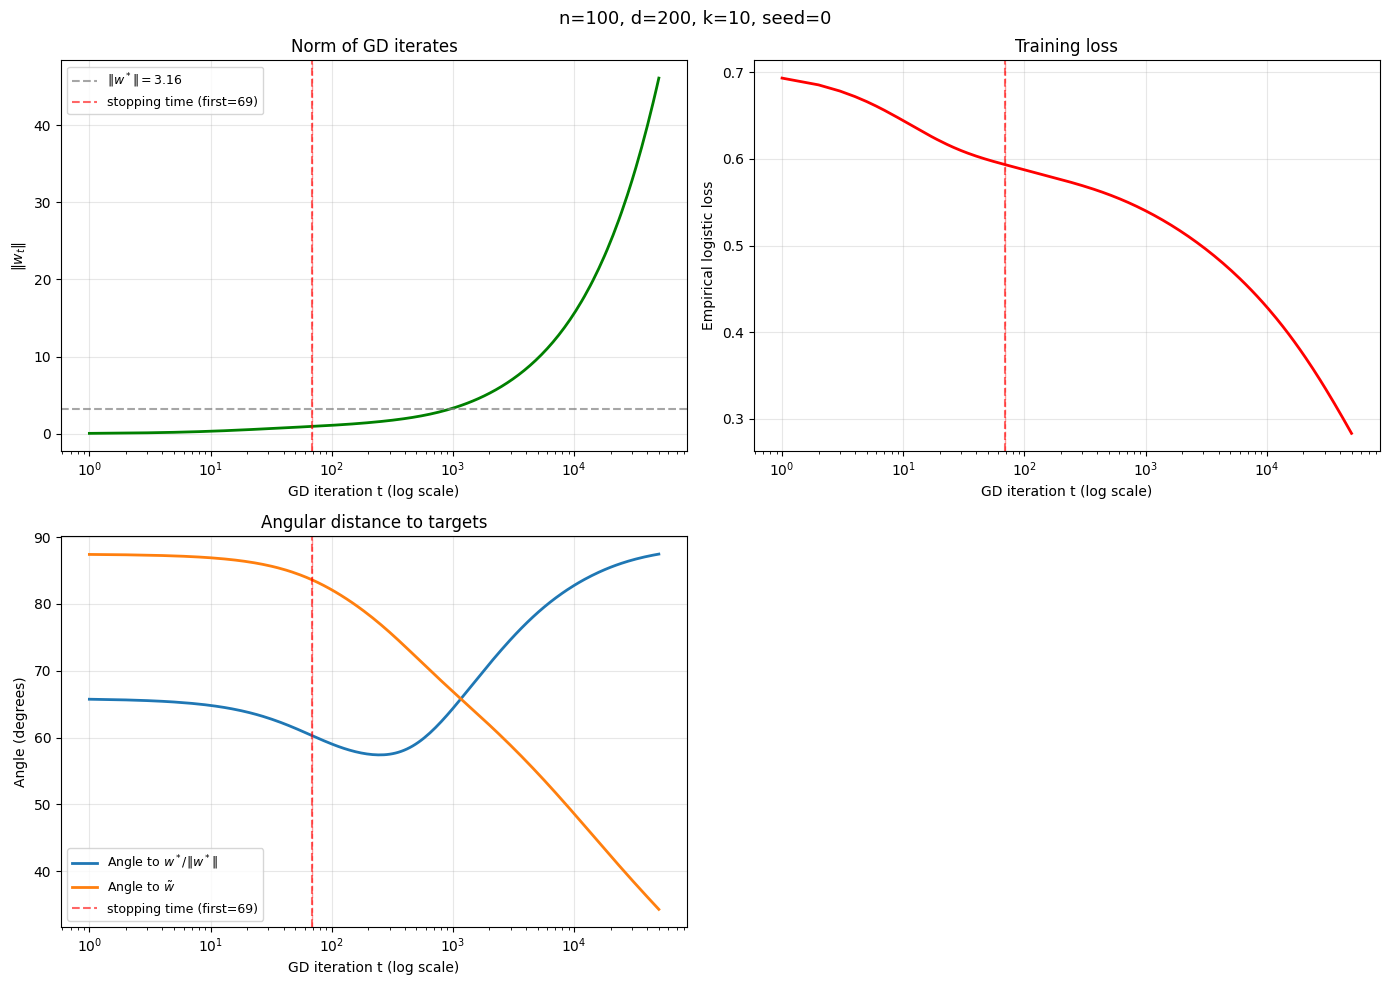


Plotting: results/run_n200_d500_k10_seed0.pkl


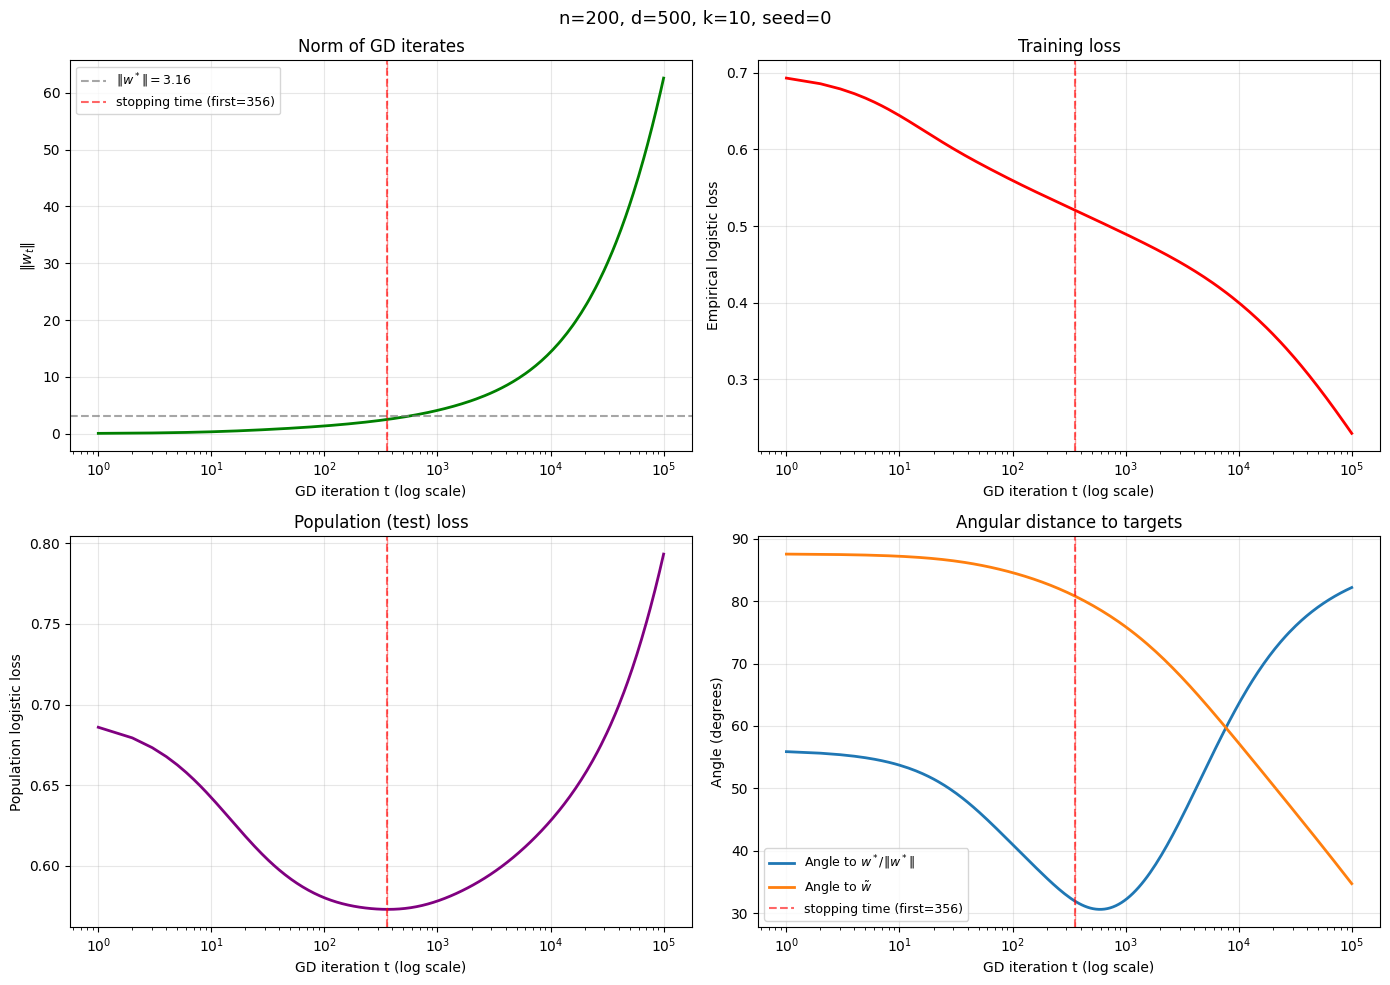


Plotting: results/run_n200_d500_k10_seed1.pkl


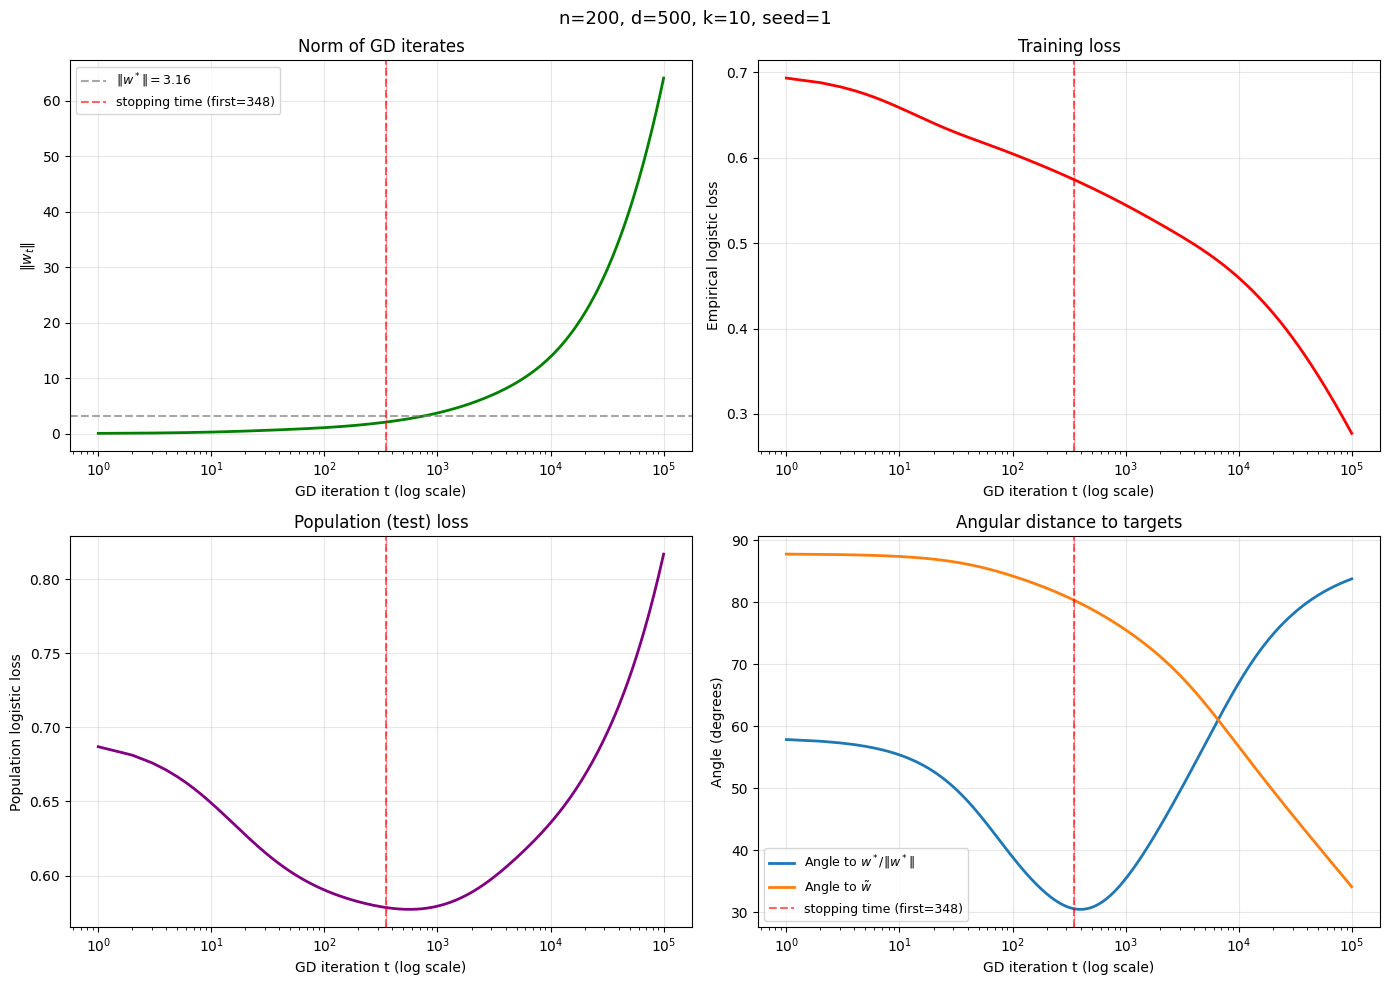


Plotting: results/run_n200_d500_k10_seed2.pkl


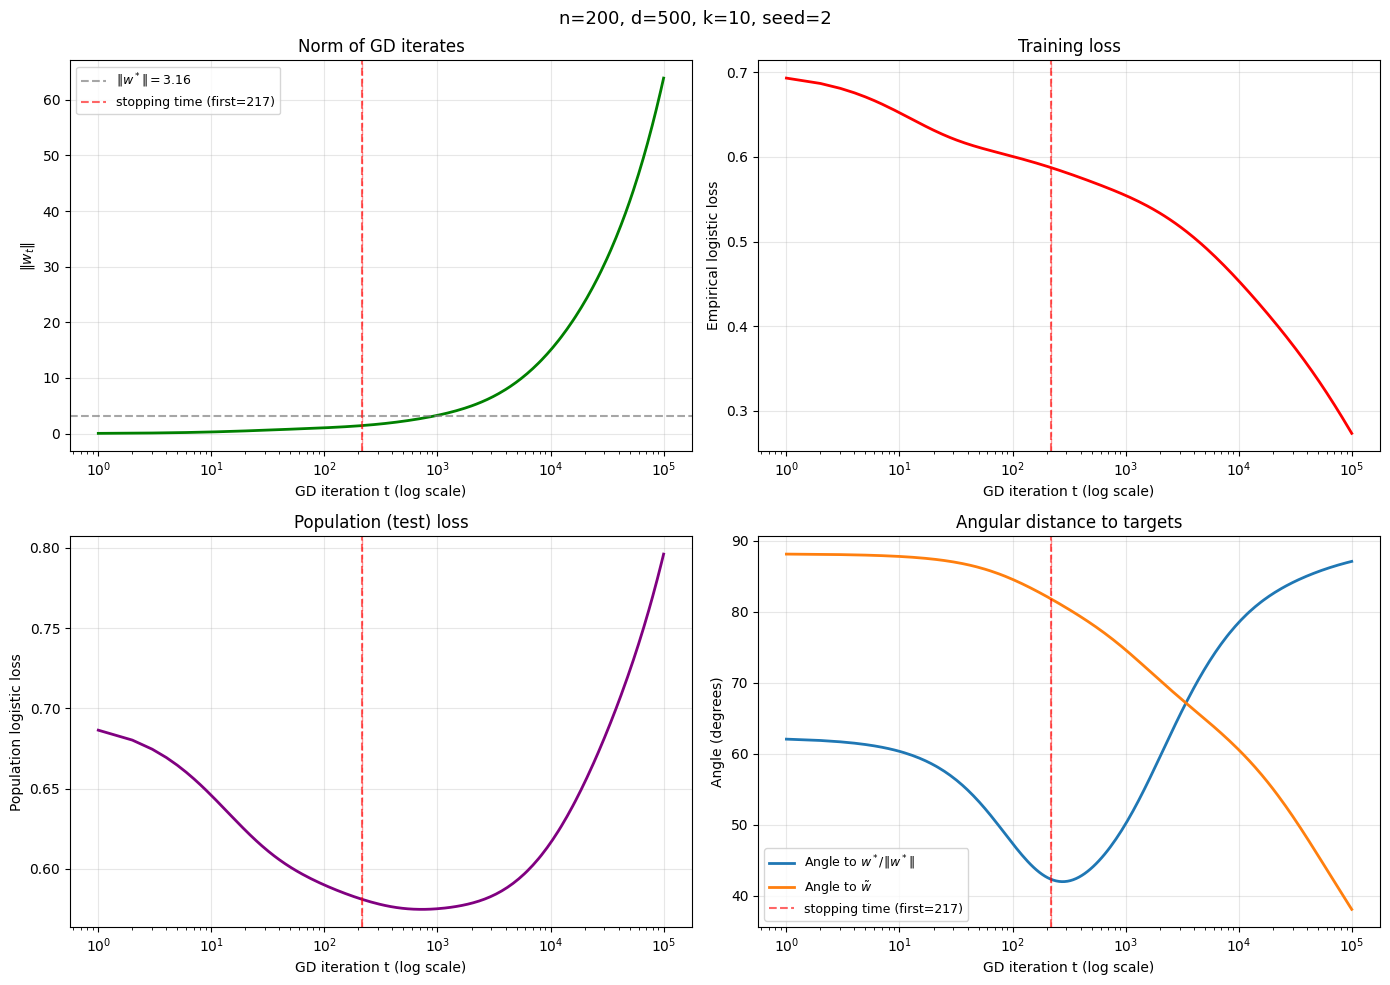


Plotting: results/run_n200_d500_k10_seed4.pkl


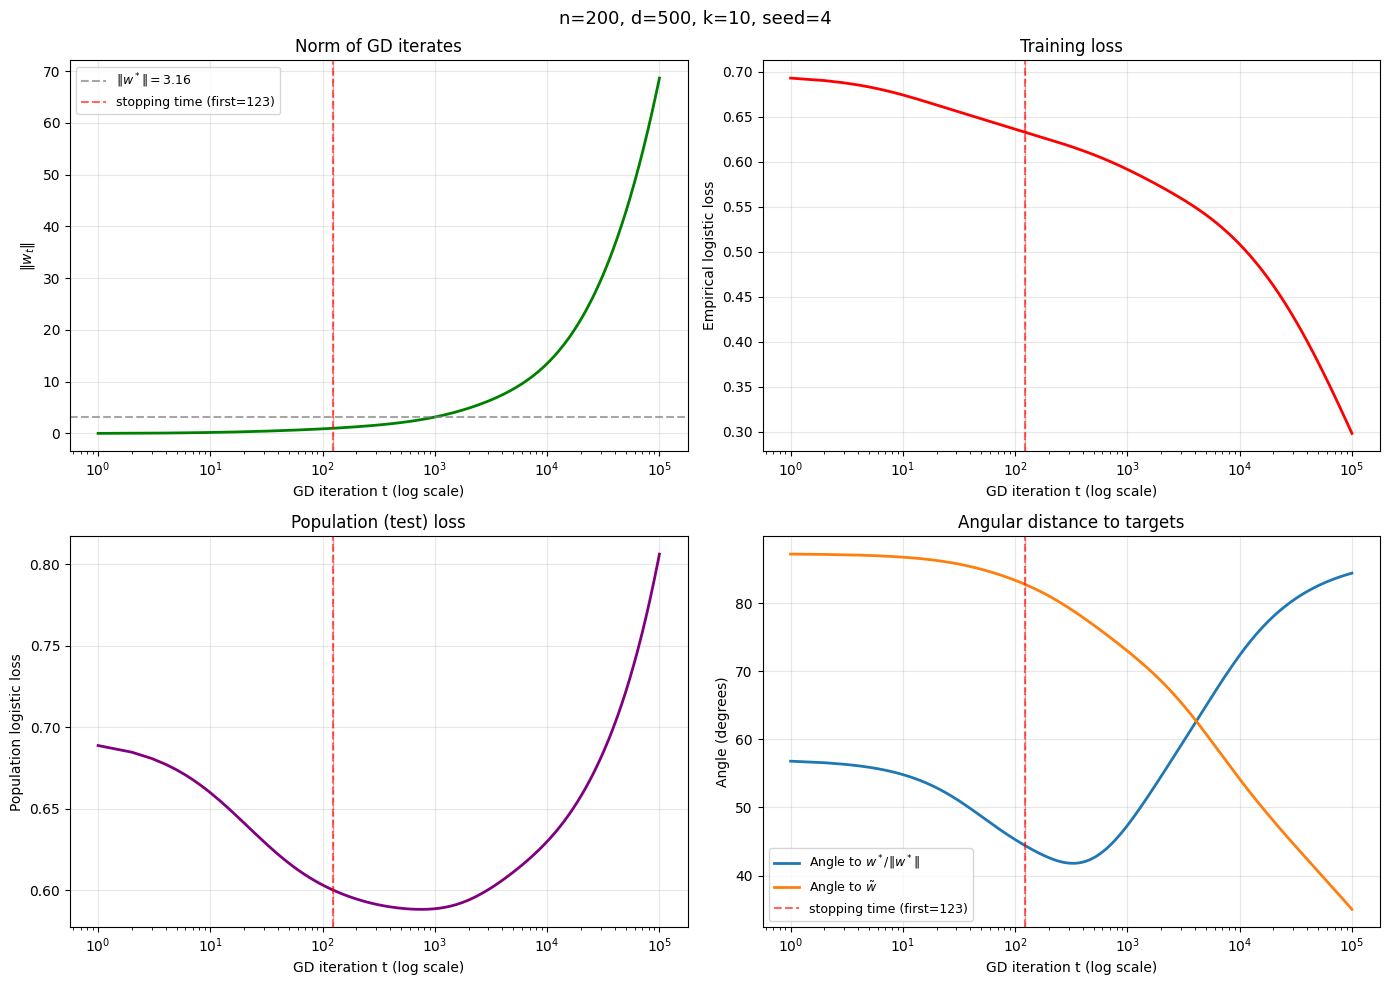

In [13]:
# Cell 3 — Plot
# Load saved .pkl files and plot. No recomputation needed.
# You can run this cell on its own, even days later.

import glob
from plotting import load_run, plot_from_data

pkl_files = sorted(glob.glob("results/run_*.pkl"))
print(f"Found {len(pkl_files)} saved runs:")
for f in pkl_files:
    print(f"  {f}")

for filepath in pkl_files:
    data = load_run(filepath)
    print(f"\nPlotting: {filepath}")
    plot_from_data(data)